In [18]:
!pip install seaborn

  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.4 MB/s eta 0:00:00a 0:00:01
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Attempting uninstall: pandas
    Found existing installation: pandas 1.1.5
    Uninstalling pandas-1.1.5:
      Successfully uninstalled pandas-1.1.5


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
!ls

 analyze_text_vec.py   help.txt			     __pycache__
 assets		       image_embedder.py	     README.md
 create_text.ipynb     inference_pipeline.py	    'report pics'
 Dataset	       input_to_image_embedd.py      scaler_x_1.0.pkl
 decoder.py	       interactive_slip_app.py	     scaler_x.pkl
 draft_memo.txt        models			     test_metrics_1.0.json
 dz.json	       models_1.0		     test_metrics.json
 embeddings	       myvenv			     text_vec_analysis.npy
 error_metrics	       parameter_distributions.png   train_pipeline.py
 error_metrics_1.0    'pipeline overview.pptx'	     tuning_pipeline.py
 extact_image.ipynb    plots


In [4]:
df = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')

df.head()

,filename,Event,EventTAG,LAT,LON,DEP,LEN_f,WID,Mw,Mo,...,HR-GPS-Data,Hr-GPS-Data,InSAR-Data,Other-Data,SAT-Data,SPOT-Data,hr-GPS-Data,inSAR-Data,level-Data,tril-Data
0,s1906SANFRA01SONG.fsp,San Francisco (Calif.),s1906SANFRA01SONG,37.78,-122.51,10.0,480.0,12.0,7.91,8.150000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s1906SANFRA01THAT.fsp,San Francisco (Calif.),s1906SANFRA01THAT,37.78,-122.51,10.0,480.0,10.0,7.91,8.120000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s1923KANTOJ01KOBA.fsp,Kanto (Japan),s1923KANTOJ01KOBA,35.40,139.20,14.6,130.0,70.0,8.08,1.460000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s1923KANTOJ01WALD.fsp,Kanto (Japan),s1923KANTOJ01WALD,35.40,139.20,14.6,130.0,70.0,7.95,9.330000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s1944TONANK01ICHI.fsp,Tonankai (Japan),s1944TONANK01ICHI,33.77,135.96,30.0,220.0,140.0,8.04,1.310000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
import os

# Path to the folder containing the images
image_folder = r'Dataset\all_images'

# Check if the folder exists
if os.path.exists(image_folder):
    # Get all files in the folder
    image_files = [f[24:-4] for f in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, f))]
    
    # Print the number of files found
    print(f"Found {len(image_files)} files in {image_folder} folder")
    
    # Display the first few filenames
    if image_files:
        print("First 5 filenames:")
        for file in image_files[:5]:
            print(file)
else:
    print(f"The folder '{image_folder}' does not exist.")

The folder 'Dataset\all_images' does not exist.


In [6]:
# Create a map for Dz values and save as JSON
import json

# Initialize the map for Dz values
dz_map = {}

# Select the columns we need (filename and Dz)
dz_cols = ['filename', 'Dz']

# Check if Dz column exists in the dataframe
if 'Dz' in df.columns:
    for row in df[dz_cols].iterrows():
        filename = row[1].values[0]  # Keep the .fsp extension for consistency
        dz_value = row[1].values[1]
        
        # Only add if Dz value is not NaN
        if not pd.isna(dz_value):
            dz_map[filename[:-4]] = float(dz_value)
    
    # Save the map as JSON
    with open('dz.json', 'w') as f:
        json.dump(dz_map, f, indent=2)
    
    print(f"Created dz.json with {len(dz_map)} entries")
    print(f"Sample entries: {dict(list(dz_map.items())[:5])}")
else:
    print("Warning: 'Dz' column not found in the dataframe")
    print(f"Available columns: {df.columns.tolist()}")



Created dz.json with 355 entries
Sample entries: {'s1906SANFRA01SONG': 12.0, 's1906SANFRA01THAT': 10.0, 's1923KANTOJ01KOBA': 10.0, 's1923KANTOJ01WALD': 10.0, 's1944TONANK01ICHI': 20.0}


In [7]:
# df_cleaned = df[df['filename'].isin(image_files)]

# df_cleaned.info()

In [8]:
df[df['avVr'] == 999]['avTr'].value_counts()

avTr
999.0    96
11.1      1
9.0       1
31.1      1
8.4       1
90.3      1
22.0      1
44.6      1
Name: count, dtype: int64

In [9]:
selected_cols= [
    'filename', # Name of the file containing the fault or subfault data
    'LAT',      # Latitude of the fault or subfault patch
    'LON',      # Longitude of the fault or subfault patch
    'DEP',      # Depth of the fault or subfault patch
    'STRK',     # Strike angle (orientation of the fault relative to North)
    'DIP',      # Dip angle (steepness of the fault plane)
    'RAKE',     # Rake angle (direction of slip)
    'LEN_f',    # Fault length (if known before the event)
    'WID',      # Fault width (if known before the event)
    'Htop',     # Depth to the top of the fault
    'HypX',     # Hypocenter location along the fault's length
    'HypZ',     # Hypocenter location along the fault's width
    'Nx',       # Number of subfaults along strike
    'Nz',       # Number of subfaults along dip
    'Dx',       # Length of each subfault patch
    'Dz',       # Width of each subfault patch
    'Mo',
    'Mw',       # Moment magnitude of the earthquake
    
]


Plotting distributions for: ['LAT', 'LON', 'DEP', 'STRK', 'DIP', 'RAKE', 'LEN_f', 'WID', 'Htop', 'HypX', 'HypZ', 'Nx', 'Nz', 'Dx', 'Dz', 'Mo', 'Mw']


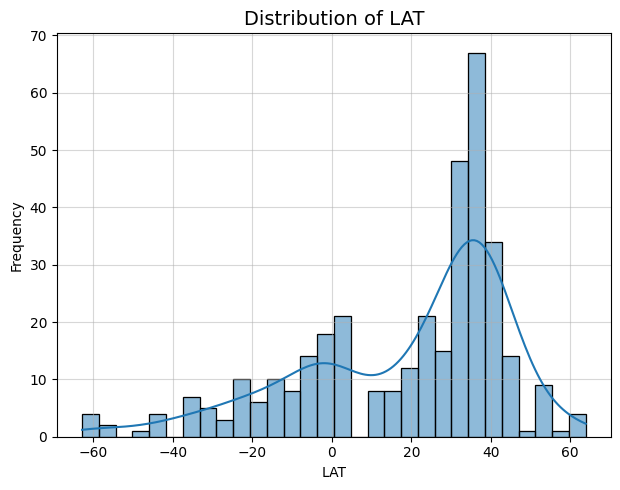

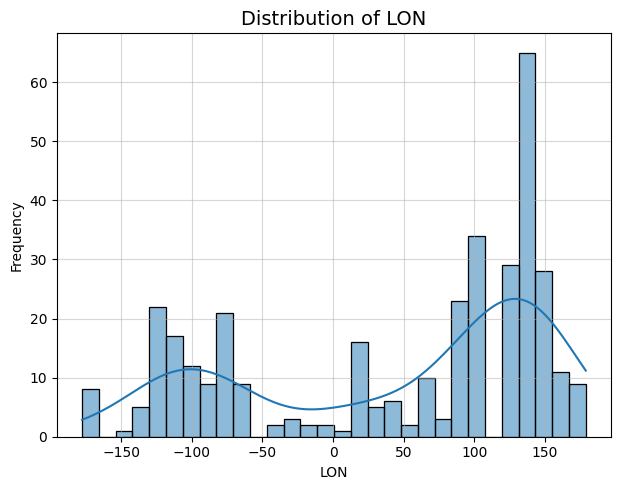

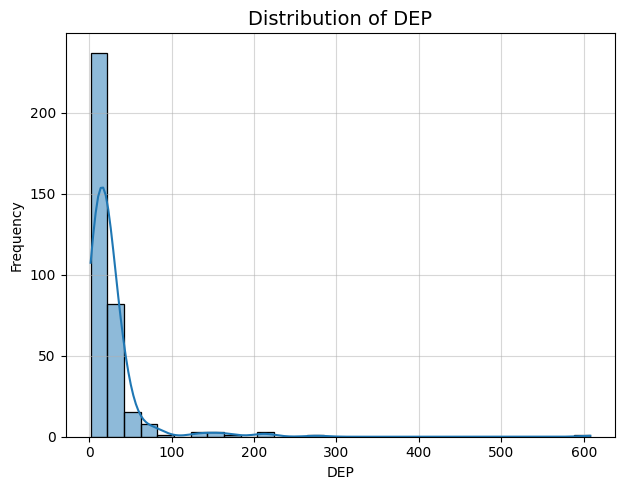

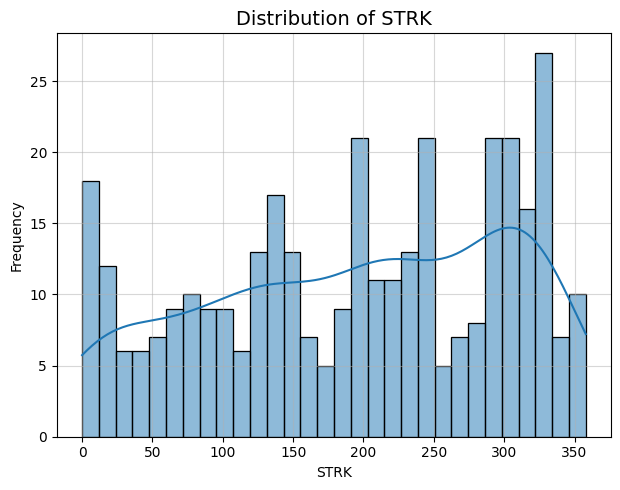

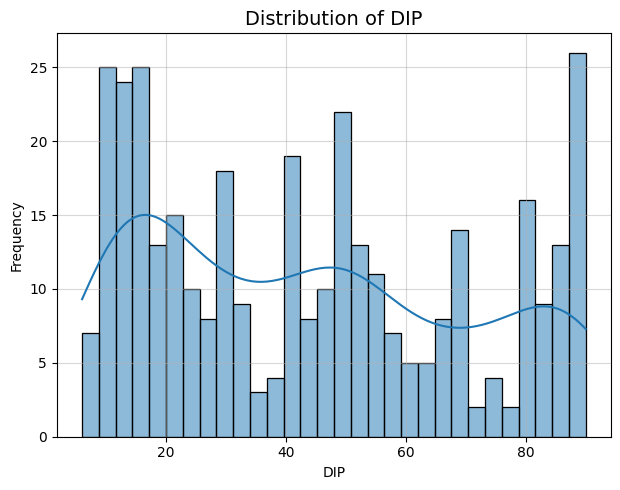

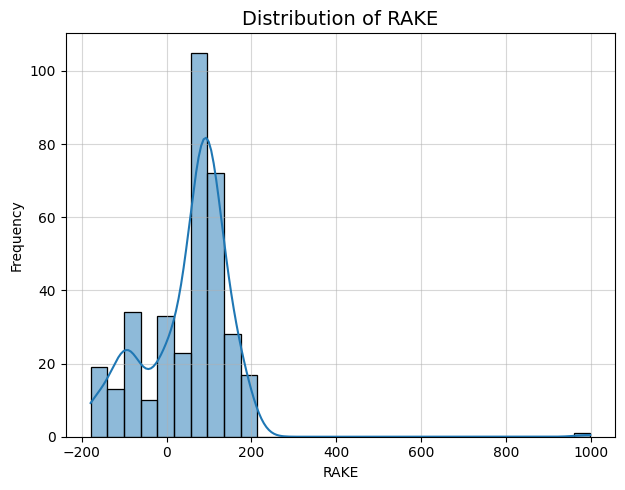

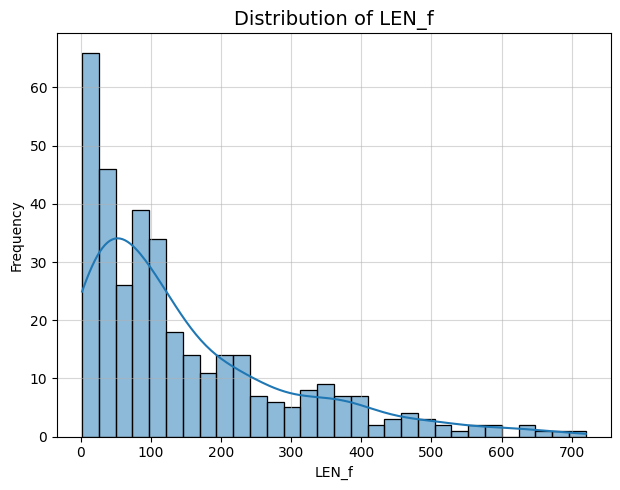

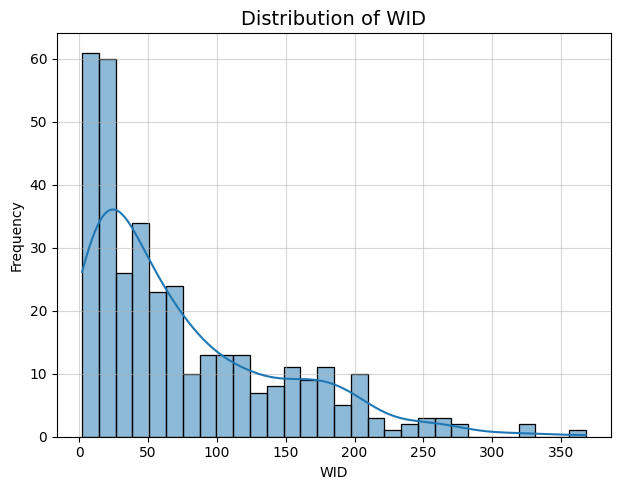

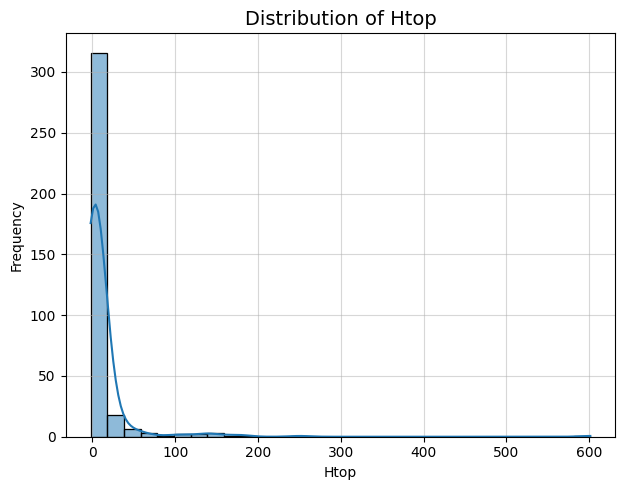

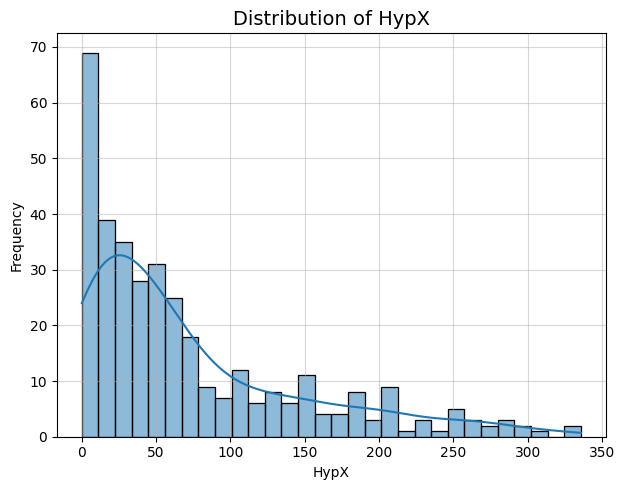

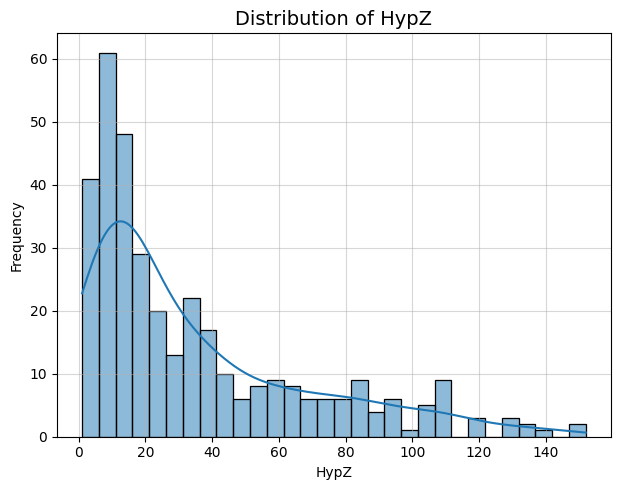

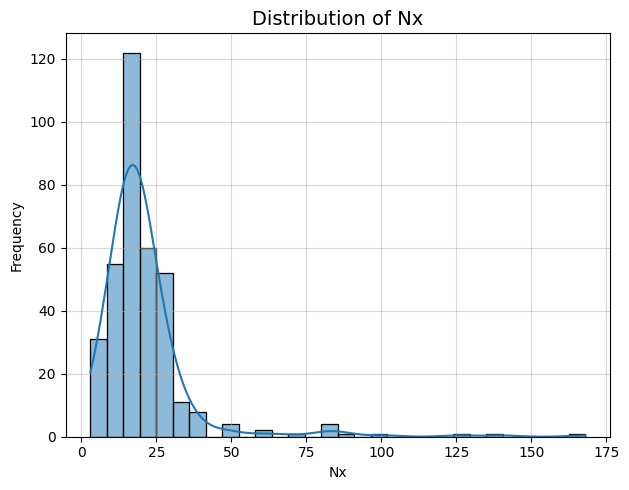

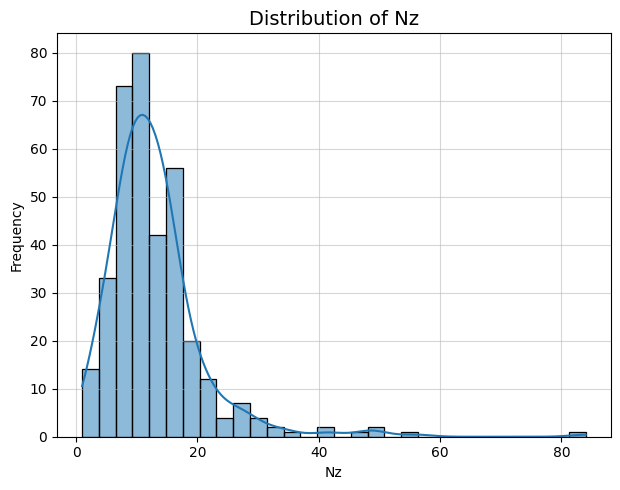

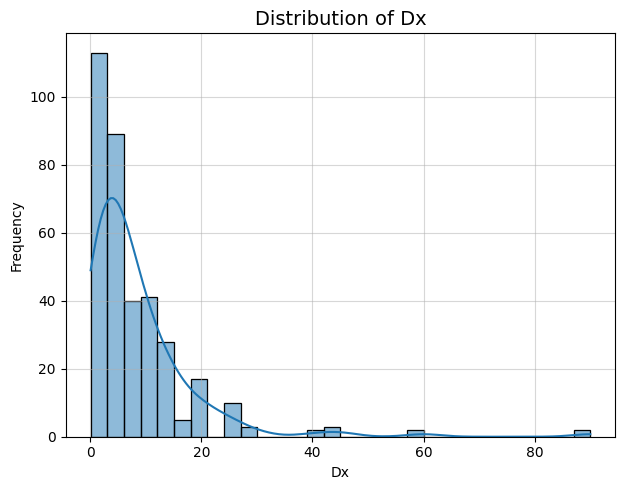

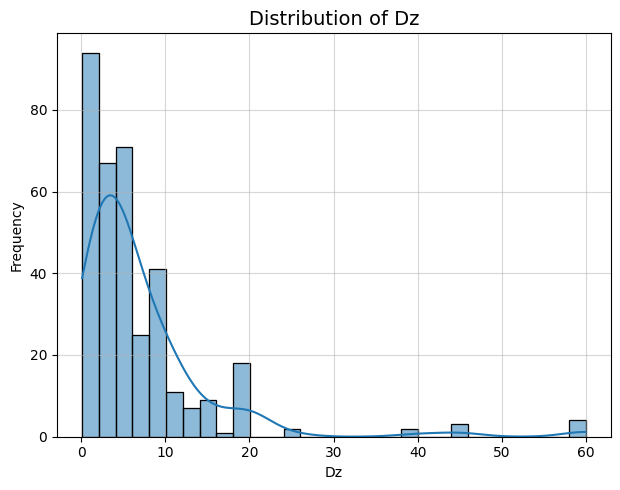

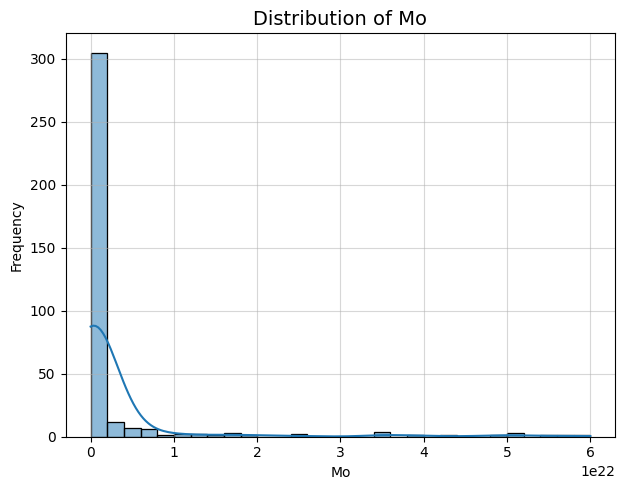

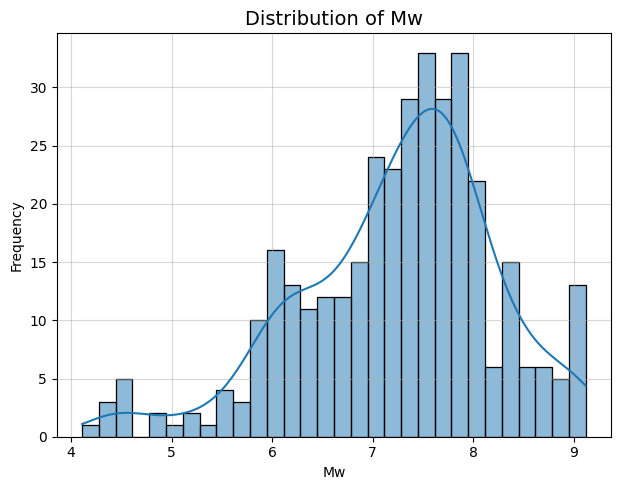

In [11]:
# --- Step 3: Plot distributions if data is loaded ---
if not df.empty:
    # Find which of the selected columns are actually in the DataFrame
    existing_cols = [col for col in selected_cols if col in df.columns]
    
    # Isolate the numerical columns for plotting
    numerical_cols = [col for col in existing_cols if pd.api.types.is_numeric_dtype(df[col])]
    
    print(f"Plotting distributions for: {numerical_cols}")

    # --- Step 4: Loop through and plot each numerical column ---
    for col in numerical_cols:
        # Plot 1: Original Distribution
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1) # Create a subplot for the original distribution
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        
        plt.grid(True, alpha=0.5)
        plt.tight_layout()
        plt.show()
else:
    print("DataFrame is empty. Cannot generate plots.")


In [12]:
selected_cols= [
    'filename', # Name of the file containing the fault or subfault data
    'LAT',      # Latitude of the fault or subfault patch
    'LON',      # Longitude of the fault or subfault patch
    'DEP',      # Depth of the fault or subfault patch
    'STRK',     # Strike angle (orientation of the fault relative to North)
    'DIP',      # Dip angle (steepness of the fault plane)
    'RAKE',     # Rake angle (direction of slip)
    'LEN_f',    # Fault length (if known before the event)
    'WID',      # Fault width (if known before the event)
    'Htop',     # Depth to the top of the fault
    'HypX',     # Hypocenter location along the fault's length
    'HypZ',     # Hypocenter location along the fault's width
    'Nx',       # Number of subfaults along strike
    'Nz',       # Number of subfaults along dip
    'Dx',       # Length of each subfault patch
    'Dz',       # Width of each subfault patch
]

log_normal_cols = [
#     'DEP',      # Depth of the fault or subfault patch
#     'Htop',     # Depth to the top of the fault
#     'HypX',     # Hypocenter location along the fault's length
#     'HypZ',     # Hypocenter location along the fault's width
    # 'Mo',
]

In [13]:
# --- Step 2: Create the map with selectively normalized features ---
feature_map = {}
c=0

# Iterate over each row of the DataFrame
for index, row in df[selected_cols].iterrows():
    filename = row['filename'][:-4]  # Remove the file extension

    # Ensure each event is processed only once
    if filename not in feature_map:
        processed_features = []
        
        # Iterate through the columns in the desired final order
        for col_name in selected_cols[1:]: # Skip 'filename'
            value = row[col_name]
            
            # Check if the column is in the list for log normalization
            if col_name in log_normal_cols:
                # Apply log10 only if the value is positive
                if value > 0:
                    processed_features.append(np.log10(value))
                else:
                    # Handle non-positive values (like Htop=0) by adding NaN
                    # This must be handled later (e.g., via imputation)
                    c+=1
                    processed_features.append(value)
            else:
                # Otherwise, keep the original raw value
                processed_features.append(value)
                
        # Store the final, processed feature vector in the dictionary
        feature_map[filename] = np.array(processed_features)

# --- Step 3: Display the result for verification ---
for name, features in feature_map.items():
    print(f"--- {name} ---")
    print("Processed Feature Vector:")
    # Printing with column names for clarity
    for col, val in zip(selected_cols[1:], features):
        print(f"  {col:<6}: {val}")
    print("-" * 25)

--- s1906SANFRA01SONG ---
Processed Feature Vector:
  LAT   : 37.78
  LON   : -122.51
  DEP   : 10.0
  STRK  : 325.0
  DIP   : 90.0
  RAKE  : 180.0
  LEN_f : 480.0
  WID   : 12.0
  Htop  : 0.0
  HypX  : 132.0
  HypZ  : 10.0
  Nx    : 48.0
  Nz    : 1.0
  Dx    : 10.0
  Dz    : 12.0
-------------------------
--- s1906SANFRA01THAT ---
Processed Feature Vector:
  LAT   : 37.78
  LON   : -122.51
  DEP   : 10.0
  STRK  : 325.0
  DIP   : 90.0
  RAKE  : 180.0
  LEN_f : 480.0
  WID   : 10.0
  Htop  : 0.0
  HypX  : 132.0
  HypZ  : 10.0
  Nx    : 48.0
  Nz    : 1.0
  Dx    : 10.0
  Dz    : 10.0
-------------------------
--- s1923KANTOJ01KOBA ---
Processed Feature Vector:
  LAT   : 35.4
  LON   : 139.2
  DEP   : 14.6
  STRK  : 290.0
  DIP   : 25.0
  RAKE  : 140.0
  LEN_f : 130.0
  WID   : 70.0
  Htop  : 2.0
  HypX  : 110.5
  HypZ  : 35.0
  Nx    : 10.0
  Nz    : 7.0
  Dx    : 13.0
  Dz    : 10.0
-------------------------
--- s1923KANTOJ01WALD ---
Processed Feature Vector:
  LAT   : 35.4
  LON   :

In [19]:
import os

def count_files_in_folder(folder_path):
    try:
        num_files = len([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])
        print(f"Total number of files in folder: {num_files}")
        return num_files
    except FileNotFoundError:
        print("Error: The folder does not exist.")
    except Exception as e:
        print(f"Error: {e}")

folder_path = '/home/kaushik/Desktop/manish/CE6018_project/Dataset/filtered_images_train'
count_files_in_folder(folder_path)

Total number of files in folder: 185


185

In [95]:
# selected_cols = ['filename', 'LEN_f', 'WID', 'RAKE', 'HypX', 'HypZ', 'Htop', 'DIP', "STRK", "Mo"]

# map = {}

# for row in df[selected_cols].iterrows():
#     filename = row[1].values[0][:-4]
#     if filename not in map:
#         map[filename] = row[1].values[1:]

In [96]:
feature_map

{'s1906SANFRA01SONG': array([  37.78, -122.51,   10.  ,  325.  ,   90.  ,  180.  ,  480.  ,
          12.  ,    0.  ,  132.  ,   10.  ,   48.  ,    1.  ,   10.  ,
          12.  ]),
 's1906SANFRA01THAT': array([  37.78, -122.51,   10.  ,  325.  ,   90.  ,  180.  ,  480.  ,
          10.  ,    0.  ,  132.  ,   10.  ,   48.  ,    1.  ,   10.  ,
          10.  ]),
 's1923KANTOJ01KOBA': array([ 35.4, 139.2,  14.6, 290. ,  25. , 140. , 130. ,  70. ,   2. ,
        110.5,  35. ,  10. ,   7. ,  13. ,  10. ]),
 's1923KANTOJ01WALD': array([ 35.4       , 139.2       ,  14.6       , 290.        ,
         25.        , 138.80831361, 130.        ,  70.        ,
          2.        , 105.        ,  29.8       ,  10.        ,
          7.        ,  13.        ,  10.        ]),
 's1944TONANK01ICHI': array([ 33.77, 135.96,  30.  , 235.  ,  20.  ,  82.  , 220.  , 140.  ,
          2.  , 190.  , 110.  ,  11.  ,   7.  ,  20.  ,  20.  ]),
 's1944TONANK01KATO': array([ 33.8 , 136.62,  30.  , 240.  ,   9.6 ,

In [97]:
import numpy as np

# Save the map as a .npy file
np.save(r'Dataset/text_vec.npy', map)
print(f"Saved text_vec.npy with {len(map)} entries")


Saved text_vec.npy with 355 entries
